<a href="https://colab.research.google.com/github/inigo99/CancerDetection/blob/main/TFM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TFM Detección de cáncer en mamografías

Íñigo Fernández Barrill

In [1]:
from IPython.display import clear_output

!wget https://unirioja-my.sharepoint.com/:u:/g/personal/infernb_unirioja_es/EbUEV-DxkwdClaZ4O8w6tOQB727Kg1Q9cQzyheUb7NddSA?download=1 -O Mamografias.zip
!unzip Mamografias.zip
clear_output()

In [2]:
!pip install fastai -Uq

In [3]:
from fastai.vision.all import *

path = Path('rsna-breast-cancer-detection_reducido_v2/')
imagesPath = path/'train_images'

In [4]:
import pandas as pd

df = pd.read_csv("rsna-breast-cancer-detection_reducido_v2/train.csv")

In [5]:
df.loc[df['image_id'] == 669289432]['cancer'].values[0]

0

In [18]:
def cadena(path):
    partes = path.split(os.path.sep)
    return partes[-1][:-4]

def label_func(fname):
    return df.loc[df['image_id'] == int(cadena(fname.name))]['cancer'].values[0]

In [19]:
db = DataBlock(blocks = (ImageBlock, CategoryBlock),
                 get_items=get_image_files, 
                 splitter=RandomSplitter(valid_pct=0.2,seed=42),
                 get_y=label_func,
                 item_tfms = Resize(512),
                 batch_tfms=aug_transforms(size=256,min_scale=0.75))

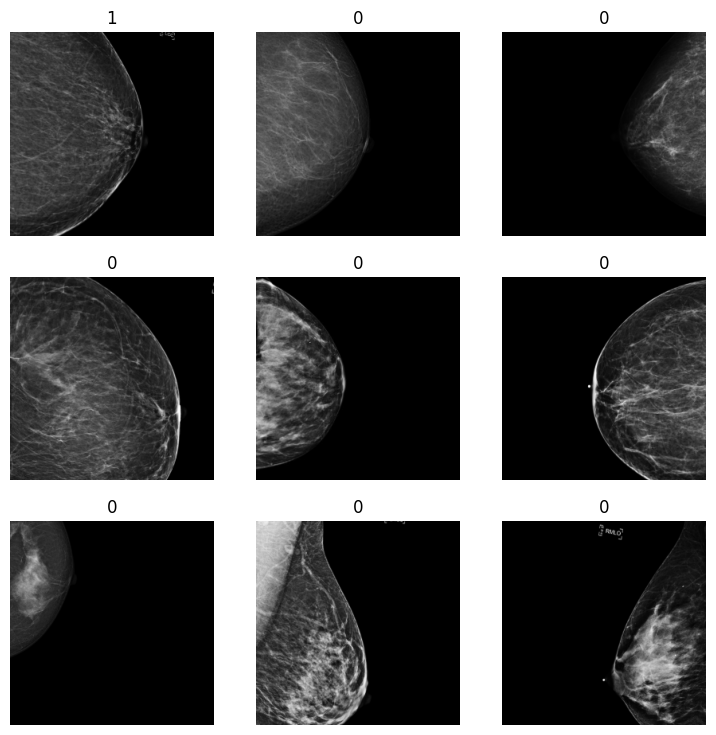

In [20]:
dls = db.dataloaders(imagesPath, bs=128)
dls.show_batch()